# Task 1: Data Cleaning and Preprocessing

## Step 1: Import Required Libraries

In [44]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

## Step 2: Load Dataset

In [45]:
df = pd.read_csv("titanic.csv")

## Step 3: Explore Dataset

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Step 4: Identify Missing Values

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Step 5: Handle Missing Values

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [9]:
df['Age'].isnull().sum()

np.int64(0)

In [10]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [11]:
df['Embarked'].isnull().sum()

np.int64(0)

In [13]:
df.drop('Cabin', axis=1, inplace=True)

In [14]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [15]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Step 6: Encode Categorical Features

In [17]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [19]:
encoder = LabelEncoder()

In [20]:
df['Sex'] = encoder.fit_transform(df['Sex'])

In [21]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S


In [22]:
df['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [23]:
df['Embarked'] = encoder.fit_transform(df['Embarked'])

In [24]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,2


## Step 7: Detect Outliers

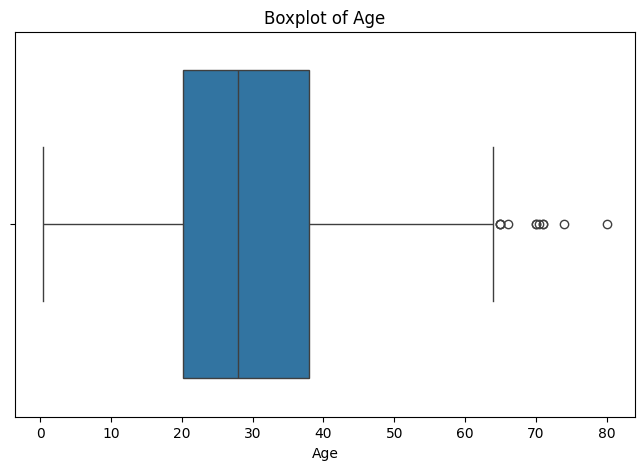

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Age'])
plt.title("Boxplot of Age")
plt.show()

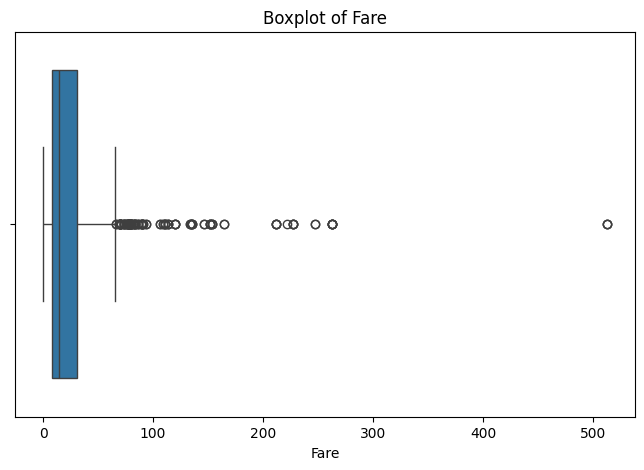

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title("Boxplot of Fare")
plt.show()

## Step 8: Remove Outliers

In [28]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Fare'] >= lower_bound) &
        (df['Fare'] <= upper_bound)]

In [29]:
df.shape

(775, 11)

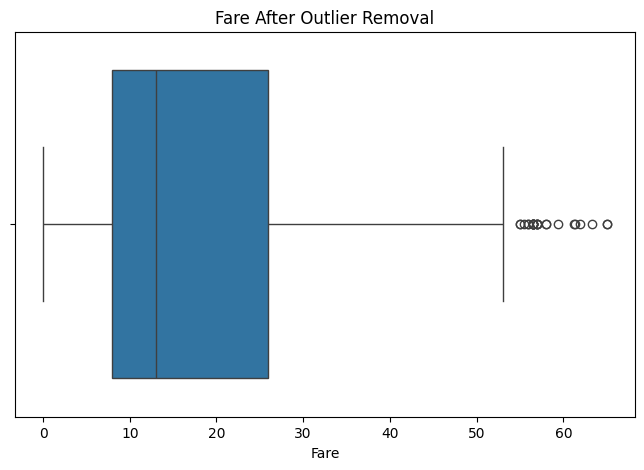

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title("Fare After Outlier Removal")
plt.show()

## Step 9: Feature Scaling

In [38]:
df = df.copy()

In [48]:
scaler = StandardScaler()

df[['Age','Fare']] = scaler.fit_transform(df[['Age','Fare']])

In [40]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,-0.528321,1,0,A/5 21171,-0.779117,2
2,3,1,3,"Heikkinen, Miss. Laina",0,-0.215182,0,0,STON/O2. 3101282,-0.729373,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,0.489381,1,0,113803,2.599828,2
4,5,0,3,"Allen, Mr. William Henry",1,0.489381,0,0,373450,-0.720161,2
5,6,0,3,"Moran, Mr. James",1,-0.058613,0,0,330877,-0.690071,1


In [41]:
df.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,775.000000,775.000000,775.00000,775.000000,7.750000e+02,775.000000,775.000000,7.750000e+02,775.000000
mean,445.806452,0.339355,2.48000,0.685161,-3.208903e-17,0.437419,0.340645,4.584147e-18,1.603871
std,260.116285,0.473796,0.73439,0.464752,1.000646e+00,0.899838,0.785914,1.000646e+00,0.734344
min,1.000000,0.000000,1.00000,0.000000,-2.217707e+00,0.000000,0.000000,-1.313411e+00,0.000000
25%,213.500000,0.000000,2.00000,0.000000,-5.283213e-01,0.000000,0.000000,-7.315244e-01,2.000000
50%,450.000000,0.000000,3.00000,1.000000,-5.861258e-02,0.000000,0.000000,-3.553671e-01,2.000000
75%,670.500000,1.000000,3.00000,1.000000,4.110961e-01,1.000000,0.000000,6.026763e-01,2.000000
max,891.000000,1.000000,3.00000,1.000000,4.012196e+00,5.000000,6.000000,3.476807e+00,2.000000


## Step 10: Save Cleaned Dataset

In [42]:
df.to_csv("cleaned_titanic.csv", index=False)

In [43]:
import os
os.listdir()

['.ipynb_checkpoints',
 'cleaned_titanic.csv',
 'Task1_Data_Preprocessing.ipynb',
 'titanic.csv']